In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\NB\AppData\Local\Temp\ipykernel_15432\1141081506.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\NB\AppData\Local\Temp\ipykernel_15432\1141081506.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


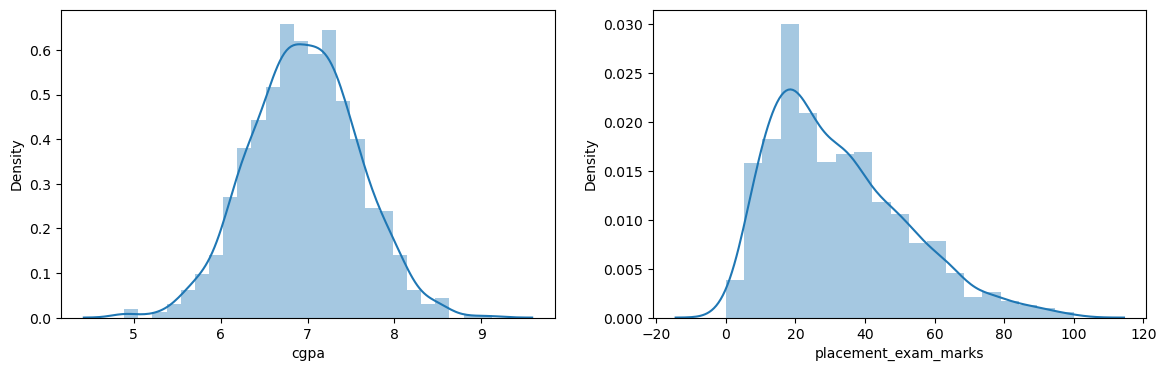

In [7]:
plt.figure(figsize = ((14,4)))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()


### as we can see that placement marks are skewed and not normal like cgpa so lets do this bitches


In [10]:
df['cgpa'].skew()


np.float64(-0.014529938929314918)

In [14]:
# as you can see that cgpa is not skewed since val is very close to 0

In [12]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [13]:
# as you can see that this is +ve so it is right skewed

In [17]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

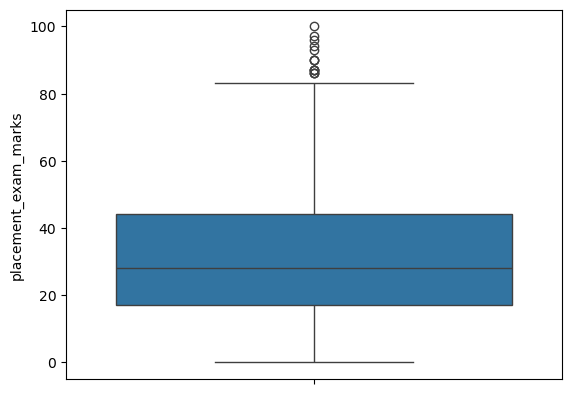

In [19]:
sns.boxplot(df['placement_exam_marks'])

In [20]:
# lets find the iqr in order to remove the outliers

In [23]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)


In [24]:
percentile75

np.float64(44.0)

In [25]:
iqr = percentile75 - percentile25

In [26]:
iqr

np.float64(27.0)

In [28]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr


In [31]:
upper_limit, lower_limit

(np.float64(84.5), np.float64(-23.5))

## Finding  the outliers

In [32]:
df[(df['placement_exam_marks'] > upper_limit )| (df['placement_exam_marks'] < lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [33]:
#  all of the above are outliers

In [34]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [35]:
new_df.shape, df.shape

((985, 3), (1000, 3))

In [36]:
# 15 outliers are removed


In [37]:
# now lets compare old and new data

C:\Users\NB\AppData\Local\Temp\ipykernel_15432\2589051648.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\NB\AppData\Local\Temp\ipykernel_15432\2589051648.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


<Axes: xlabel='placement_exam_marks'>

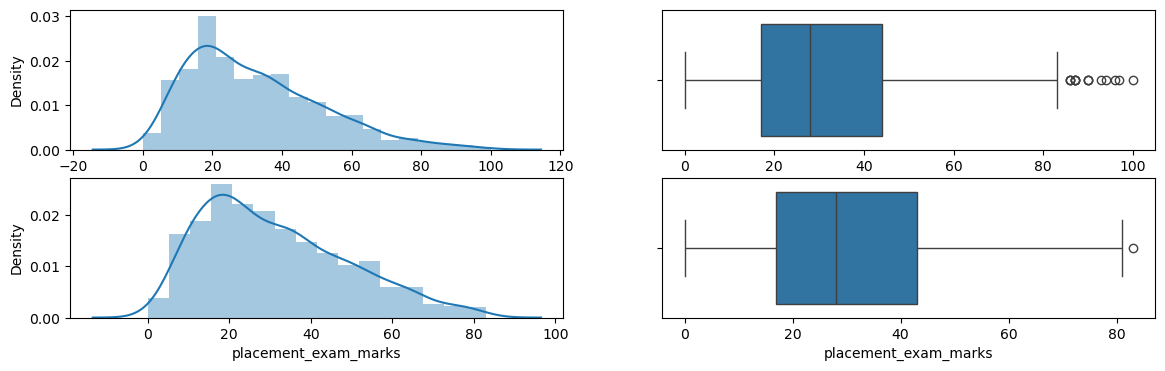

In [42]:
plt.figure(figsize = ((14,4)))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot (x = df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x = new_df['placement_exam_marks'])


In [43]:
# just one outlier is left with trimming

## Capping

In [51]:
new_df_cap = df.copy()

In [53]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [54]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


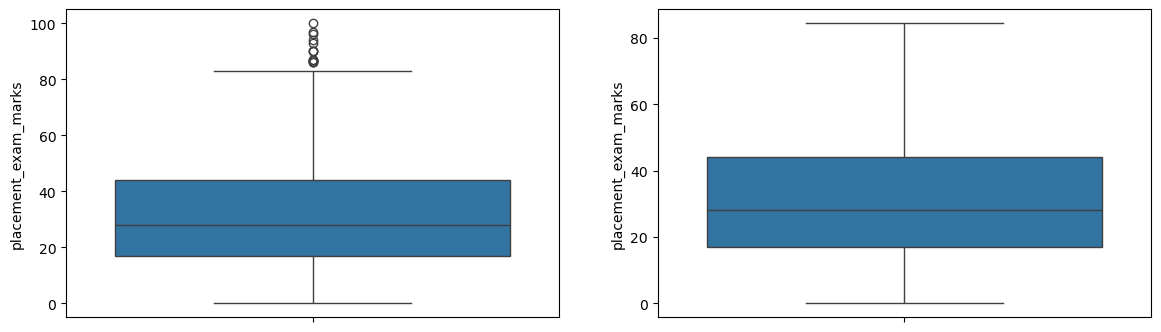

In [55]:
plt.figure(figsize = ((14,4)))

plt.subplot(1,2,1)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(1,2,2)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()

#### now if you see all of the outliers are removed